# The Agent-Environment Loop

This notebook explains the fundamental AXIS loop:

`observe -> decide -> act -> world evolves -> observe -> transition`

Primary focus:
- why this loop abstraction was chosen at all
- system vs framework vs world responsibilities
- how behavior emerges from the closed loop rather than from the agent alone
- how persisted traces make the loop inspectable

The running example is a persisted `system_aw` episode from the `system_aw-baseline` workspace.


In [1]:
from _bootstrap import setup_notebook

ROOT = setup_notebook()


## Why This Loop Exists

The AXIS loop should not be read as a merely convenient software API. It is a deliberate abstraction chosen for both research and engineering reasons.

On the research side, AXIS is trying to study **adaptive behavior as an emergent property of agent-environment coupling**. That already suggests a loop structure rather than a one-shot function from input to output. Biologically, the relevant inspiration is not that AXIS copies any one organism in detail, but that organisms exist in a continuous perception-action cycle:

- they sense only a local, partial view of the world
- they select actions under internal pressures such as hunger or exploration
- the world changes both because of the action and because the world has its own dynamics
- they then update internal state from the resulting consequences

That is a much closer fit to a closed-loop control picture than to a feedforward "compute answer once" picture.

On the engineering side, AXIS needs a loop structure that preserves three properties at once:

- the **system** remains mechanistically interpretable
- the **framework** can own execution, persistence, and comparison
- the **world** remains a first-class causal participant rather than passive scenery


## Why Not Simpler Alternatives?

The current design becomes clearer when contrasted with nearby alternatives.

### Alternative 1: Monolithic `system.step(...)`

A single opaque step method would be simpler to call, but it would hide the most important boundary in AXIS: the boundary between **action selection** and **world mutation**. If the framework cannot see that boundary, it becomes much harder to:

- persist structured traces
- compare systems under the same world mutation semantics
- keep system internals opaque while still making the episode loop framework-owned

### Alternative 2: Let the System Mutate the World Directly

This would collapse system logic and environment dynamics into one procedural blob. That would weaken one of the core AXIS commitments:

> systems define behavior tendencies, but the framework/world layer owns what actually happens in the environment.

If the system mutated the world directly, we would lose a clean way to ask whether a behavioral difference came from:

- a different internal mechanism
- a different world rule
- or a different orchestration contract

### Alternative 3: No Separate Transition Phase

Without a post-outcome transition phase, internal state update would either have to happen inside decision-making or be mixed into world application. That would be a poor fit for both biology and analysis.

Biologically, internal state changes happen *because of outcomes*.
Architecturally, energy, memory, and termination should update **after** the action outcome and fresh observation are available.

The `decide()` / `transition()` split is therefore not accidental. It is the minimal decomposition that keeps:

- world mutation framework-owned
- state mutation system-owned
- the whole step traceable


## Biological Motivation, Without Overclaiming

AXIS is not a biological simulation. Still, the loop abstraction is biologically motivated in a disciplined way.

The useful analogies are:

- **organism-environment coupling**: behavior is produced in interaction, not in isolation
- **homeostatic pressure**: internal variables such as energy matter for action selection
- **perception-action cycling**: observations guide action, outcomes change future observations
- **stateful adaptation**: memory and internal traces matter across timesteps

The useful non-claim is equally important:

- AXIS does **not** claim that biological cognition is exhausted by this loop
- it claims only that this loop is a productive minimal scaffold for studying mechanistic adaptive behavior

That is why the loop is intentionally simple, but not arbitrary.

### Why Discrete Steps?

Biological processes are not naturally chopped into neat simulation timesteps. Organisms live in ongoing, partially overlapping, effectively quasi-continuous dynamics. So AXIS has to make a modeling choice here.

The choice of **discrete steps** is deliberate. We discretize not because continuity is philosophically unimportant, but because a stepwise model gives us a tractable unit in which we can still preserve the main causal structure we care about:

- a local observation
- an action selection event
- world-side dynamics
- an action outcome
- a state update inside the agent

In other words, one AXIS step should be read as a **causal analysis window**, not as a claim that biology literally advances in ticks.

### What We Gain By Discretizing

- we can make the perception-action-update cycle explicit
- we can assign responsibility boundaries cleanly between system, framework, and world
- we can persist replayable traces at a granularity that is still interpretable by a human reader
- we can compare different systems and worlds under the same execution contract

### What We Lose Or Distort

Discretization also has real consequences, and the notebook should acknowledge them.

- some processes that would be concurrent in biology become sequentialized in the model
- the chosen timestep granularity determines what counts as "one decision" or "one outcome"
- fast sub-step dynamics are compressed into one transition window
- some feedback effects may depend on timestep size rather than only on mechanism structure

So AXIS should not be read as saying that cognition is inherently discrete. The more modest claim is:

> a discrete loop is a useful research abstraction for studying mechanistic adaptive behavior, provided we stay aware of the abstractions it imposes.



## Where The Loop Lives In The Code

Two code locations matter most:

- `src/axis/sdk/interfaces.py`
  defines the system contract, especially `decide()` and `transition()`
- `src/axis/framework/runner.py`
  implements the framework-owned episode loop

The key architectural fact is that **systems do not run themselves**. The framework orchestrates the loop and asks the system for the parts it owns.


In [2]:
import pandas as pd
from IPython.display import display

from research.lib import load_json
from research.lib.plotting import lines_plot
from axis.sdk.trace import DeltaEpisodeTrace, reconstruct_episode_trace

WORKSPACE = ROOT / 'workspaces' / 'system_aw-baseline'
EPISODE_PATH = (
    WORKSPACE
    / 'series'
    / 'world-variations'
    / 'results'
    / 'e364d733f3234359a4a1b40bed448772'
    / 'runs'
    / 'run-0000'
    / 'episodes'
    / 'episode_0001.json'
)

delta_episode = DeltaEpisodeTrace.model_validate(load_json(EPISODE_PATH))
full_episode = reconstruct_episode_trace(delta_episode)

print('Episode artifact:', EPISODE_PATH.relative_to(ROOT))
print('Episode system type:', full_episode.system_type)
print('Episode termination reason:', full_episode.termination_reason)
print('Episode total steps:', full_episode.total_steps)



Episode artifact: workspaces/system_aw-baseline/series/world-variations/results/e364d733f3234359a4a1b40bed448772/runs/run-0000/episodes/episode_0001.json
Episode system type: system_aw
Episode termination reason: max_steps_reached
Episode total steps: 200


| Phase | Owner | Role | Why It Matters |
| --- | --- | --- | --- |
| `observe` (pre-decision) | system | construct a system-specific local observation from the current world view | keeps perception system-specific and partial |
| `decide` | system | combine observation, internal state, drives, and policy into an action intent | action selection remains system-internal and interpretable |
| `world evolves` | world/framework | apply autonomous world dynamics such as regeneration | the environment has its own causal contribution |
| `act` | framework/world | apply the chosen action through world action handlers | systems do not mutate the world directly |
| `observe` (post-action) | system | sense the world again after dynamics and action consequences | transition uses the resulting world state, not a guessed one |
| `transition` | system | update internal state, memory, vitality, and termination status | state mutation remains system-owned and outcome-dependent |



A small but important implementation detail: the concrete runner order is slightly more explicit than the compact conceptual slogan.

In the actual framework step, the world first advances its own dynamics, then the chosen action is applied, then the system observes the resulting post-action state and transitions. That refinement is useful, not a contradiction. It makes the environment's independent dynamics visible in the trace.


| View | Loop |
| --- | --- |
| conceptual notebook slogan | `observe -> decide -> act -> world evolves -> observe -> transition` |
| framework runtime refinement | `snapshot -> decide -> world.tick -> apply action -> observe -> transition -> trace` |



## Episode Trace As The Bridge Between Execution And Explanation

The persisted episode we loaded is a **delta trace**. That means the artifact stores:

- the initial world snapshot
- a per-step regeneration delta
- a per-step action delta
- system-specific decision and transition data

This is already a methodological statement. AXIS does not treat traces as disposable logs. It treats them as reconstructable causal records.


In [3]:
trace_schema_df = pd.DataFrame(
    [
        ('episode result type', delta_episode.result_type),
        ('system type', delta_episode.system_type),
        ('total steps', delta_episode.total_steps),
        ('termination reason', delta_episode.termination_reason),
        ('step fields', ', '.join(delta_episode.steps[0].model_dump().keys())),
    ],
    columns=['field', 'value'],
)

display(trace_schema_df)


,field,value
0,episode result type,delta_episode
1,system type,system_aw
2,total steps,200
3,termination reason,max_steps_reached
4,step fields,"timestep, action, regen_delta, action_delta, a..."


## A Short Local Sequence

Before diving into one step in detail, it helps to look at a short local sequence. That makes the loop feel like a dynamical process rather than a static schema.


In [4]:
step_rows = []
for step in full_episode.steps[:12]:
    decision = step.system_data['decision_data']
    trace = step.system_data['trace_data']
    step_rows.append(
        {
            'timestep': step.timestep,
            'action': step.action,
            'position_before': f"({step.agent_position_before.x}, {step.agent_position_before.y})",
            'position_after': f"({step.agent_position_after.x}, {step.agent_position_after.y})",
            'vitality_before': step.vitality_before,
            'vitality_after': step.vitality_after,
            'hunger_activation': decision['hunger_drive']['activation'],
            'curiosity_activation': decision['curiosity_drive']['activation'],
            'hunger_weight': decision['arbitration']['hunger_weight'],
            'curiosity_weight': decision['arbitration']['curiosity_weight'],
            'energy_delta': trace['energy_delta'],
        }
    )

sequence_df = pd.DataFrame(step_rows)
display(sequence_df)


,timestep,action,position_before,position_after,vitality_before,vitality_after,hunger_activation,curiosity_activation,hunger_weight,curiosity_weight,energy_delta
0,0,up,"(10, 10)","(10, 9)",1.00,0.99,0.00,1.000000,0.30000,1.0000,-1.0
1,1,left,"(10, 9)","(9, 9)",0.99,0.98,0.01,1.000000,0.30007,0.9801,-1.0
2,2,down,"(9, 9)","(9, 10)",0.98,0.97,0.02,1.000000,0.30028,0.9604,-1.0
3,3,down,"(9, 10)","(9, 11)",0.97,0.96,0.03,1.000000,0.30063,0.9409,-1.0
4,4,left,"(9, 11)","(8, 11)",0.96,0.95,0.04,1.000000,0.30112,0.9216,-1.0
5,5,down,"(8, 11)","(8, 12)",0.95,0.94,0.05,1.000000,0.30175,0.9025,-1.0
6,6,down,"(8, 12)","(8, 13)",0.94,0.93,0.06,1.000000,0.30252,0.8836,-1.0
7,7,down,"(8, 13)","(8, 14)",0.93,0.92,0.07,0.995714,0.30343,0.8649,-1.0
8,8,left,"(8, 14)","(7, 14)",0.92,0.91,0.08,0.991797,0.30448,0.8464,-1.0
9,9,up,"(7, 14)","(7, 13)",0.91,0.90,0.09,0.988148,0.30567,0.8281,-1.0


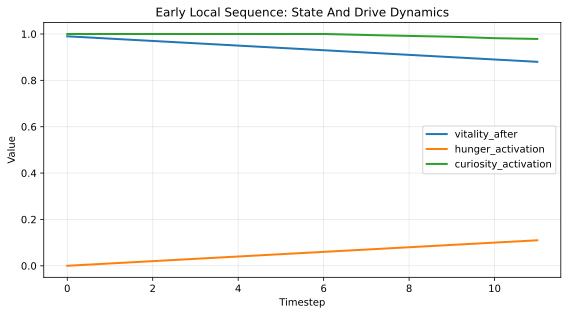

In [5]:
fig, ax = lines_plot(
    [
        {'x': sequence_df['timestep'], 'y': sequence_df['vitality_after'], 'label': 'vitality_after'},
        {'x': sequence_df['timestep'], 'y': sequence_df['hunger_activation'], 'label': 'hunger_activation'},
        {'x': sequence_df['timestep'], 'y': sequence_df['curiosity_activation'], 'label': 'curiosity_activation'},
    ],
    title='Early Local Sequence: State And Drive Dynamics',
    xlabel='Timestep',
    ylabel='Value',
)


Even in these early steps, the loop is already doing several things at once:

- the world is changing through regeneration
- the agent is moving through that changing world
- vitality is decreasing due to action cost
- hunger begins to rise from that energetic change
- curiosity responds to novelty and world-model state

This is exactly why AXIS treats behavior as loop-generated rather than agent-generated.


## One Step, Deeply Inspected

For the deep dive, step `50` is a good example because it includes a `consume` action. That makes the separation between world change and internal state change especially visible.


In [6]:
deep_step = full_episode.steps[50]
deep_decision = deep_step.system_data['decision_data']
deep_trace = deep_step.system_data['trace_data']
deep_delta_step = delta_episode.steps[50]

deep_step_summary = pd.DataFrame(
    [
        ('timestep', deep_step.timestep),
        ('action', deep_step.action),
        ('position_before', f"({deep_step.agent_position_before.x}, {deep_step.agent_position_before.y})"),
        ('position_after', f"({deep_step.agent_position_after.x}, {deep_step.agent_position_after.y})"),
        ('vitality_before', deep_step.vitality_before),
        ('vitality_after', deep_step.vitality_after),
        ('regen_changed_cells', len(deep_delta_step.regen_delta.changed_cells)),
        ('action_changed_cells', len(deep_delta_step.action_delta.changed_cells)),
        ('termination_flag', deep_step.terminated),
    ],
    columns=['field', 'value'],
)

display(deep_step_summary)


,field,value
0,timestep,50
1,action,consume
2,position_before,"(15, 17)"
3,position_after,"(15, 17)"
4,vitality_before,0.5
5,vitality_after,0.5715
6,regen_changed_cells,32
7,action_changed_cells,1
8,termination_flag,False


In [7]:
observation_df = pd.DataFrame(
    [
        ('current', deep_decision['observation']['current']['traversability'], deep_decision['observation']['current']['resource']),
        ('up', deep_decision['observation']['up']['traversability'], deep_decision['observation']['up']['resource']),
        ('down', deep_decision['observation']['down']['traversability'], deep_decision['observation']['down']['resource']),
        ('left', deep_decision['observation']['left']['traversability'], deep_decision['observation']['left']['resource']),
        ('right', deep_decision['observation']['right']['traversability'], deep_decision['observation']['right']['resource']),
    ],
    columns=['direction', 'traversability', 'resource'],
)

drive_df = pd.DataFrame(
    [
        ('hunger_activation', deep_decision['hunger_drive']['activation']),
        ('curiosity_activation', deep_decision['curiosity_drive']['activation']),
        ('hunger_weight', deep_decision['arbitration']['hunger_weight']),
        ('curiosity_weight', deep_decision['arbitration']['curiosity_weight']),
        ('selected_action', deep_decision['policy']['selected_action']),
    ],
    columns=['quantity', 'value'],
)

policy_df = pd.DataFrame(
    {
        'action_index': list(range(len(deep_decision['combined_scores']))),
        'combined_score': deep_decision['combined_scores'],
        'admissible': deep_decision['policy']['admissibility_mask'],
        'probability': deep_decision['policy']['probabilities'],
    }
)

display(observation_df)
display(drive_df)
display(policy_df)


,direction,traversability,resource
0,current,1.0,0.5
1,up,1.0,0.0
2,down,1.0,0.0
3,left,1.0,0.0
4,right,0.0,0.0


,quantity,value
0,hunger_activation,0.5
1,curiosity_activation,0.938148
2,hunger_weight,0.475
3,curiosity_weight,0.25
4,selected_action,consume


,action_index,combined_score,admissible,probability
0,0,0.016772,True,0.210039
1,1,0.026746,True,0.232068
2,2,0.026817,True,0.232231
3,3,0.066268,False,0.000000
4,4,0.036662,True,0.256259
5,5,-0.093963,True,0.069404


In [8]:
outcome_df = pd.DataFrame(
    [
        ('energy_before', deep_trace['energy_before']),
        ('action_cost', deep_trace['action_cost']),
        ('energy_gain', deep_trace['energy_gain']),
        ('energy_after', deep_trace['energy_after']),
        ('energy_delta', deep_trace['energy_delta']),
        ('buffer_entries_before', deep_trace['buffer_entries_before']),
        ('buffer_entries_after', deep_trace['buffer_entries_after']),
        ('visit_count_at_current', deep_trace['visit_count_at_current']),
    ],
    columns=['transition_quantity', 'value'],
)

action_delta_df = pd.DataFrame(
    [
        {
            'changed_x': update.position.x,
            'changed_y': update.position.y,
            'cell_type_after_action': update.cell.cell_type,
            'resource_value_after_action': update.cell.resource_value,
        }
        for update in deep_delta_step.action_delta.changed_cells
    ]
)

display(outcome_df)
display(action_delta_df)


,transition_quantity,value
0,energy_before,50.00
1,action_cost,0.50
2,energy_gain,7.65
3,energy_after,57.15
4,energy_delta,7.15
5,buffer_entries_before,50.00
6,buffer_entries_after,50.00
7,visit_count_at_current,4.00


,changed_x,changed_y,cell_type_after_action,resource_value_after_action
0,15,17,empty,0.0


### Reading The Deep-Dive Step

This one step already shows why the two-phase design matters.

1. The **system** sees a local observation and computes drive-structured decision data.
2. The **framework/world** applies autonomous regeneration and then the selected action.
3. The **system** then transitions from the actual outcome, not from an imagined one.

The `consume` example makes this especially clear:

- the action delta shows that the cell content changed in the world
- the transition data shows that energy increased in the agent state
- those are related, but not identical, events

That separation is exactly what would blur together in a direct-mutation or monolithic-step design.


## System, Framework, World: Responsibility Split

The loop only stays interpretable because responsibilities are separated.


| Layer | Owns | Does Not Own |
| --- | --- | --- |
| system | observation model, drives, arbitration, policy, internal state transition | world mutation, experiment orchestration, persistence |
| framework | episode execution, trace assembly, persistence, comparison, workspace routing | system-specific cognition or world-specific semantics |
| world | mutable environment state, autonomous dynamics, action consequences | agent internal state or action selection policy |



This split supports both major AXIS goals at once:

- **behavioral clarity**: the same system can be studied across different worlds, and the same world logic can be studied across different systems
- **architectural clarity**: traces, comparisons, and replay can be built once at the framework level instead of being entangled with one concrete agent implementation


## Why Worlds Shape Behavior

A subtle but important consequence of the loop is that the world is not just a source of observations. It is a causal process with its own timing and dynamics.

In the runtime contract, regeneration happens in the step itself and is preserved in the trace as `AFTER_REGEN` / `regen_delta`. This means that the agent is always acting in a world that is both:

- constrained by the current geometry and resource layout
- already evolving independently of the chosen action

That is one reason AXIS claims should usually be framed as **system-in-world** claims, not system-only claims.


In [9]:
world_change_df = pd.DataFrame(
    [
        ('step_0_regen_changed_cells', len(delta_episode.steps[0].regen_delta.changed_cells)),
        ('step_0_action_changed_cells', len(delta_episode.steps[0].action_delta.changed_cells)),
        ('step_50_regen_changed_cells', len(delta_episode.steps[50].regen_delta.changed_cells)),
        ('step_50_action_changed_cells', len(delta_episode.steps[50].action_delta.changed_cells)),
    ],
    columns=['quantity', 'value'],
)

display(world_change_df)


,quantity,value
0,step_0_regen_changed_cells,32
1,step_0_action_changed_cells,0
2,step_50_regen_changed_cells,32
3,step_50_action_changed_cells,1


Even when the chosen action changes no cells directly, the world may still have changed during the same step because regeneration already occurred. This is an important conceptual guardrail:

> the episode trace is recording coupled causation, not just agent commands.


## Why Traces Matter Methodologically

At this point the methodological claim from the previous notebook should feel more concrete.

A trace is not just an audit trail saying that an action happened. In AXIS it is the primary object that lets us align:

- what the system could locally sense
- what it internally computed
- what the world changed independently
- what the action changed additionally
- how the system state evolved afterward

Without that structure, mechanistic explanation would collapse back into storytelling.


| Question | Trace Location |
| --- | --- |
| What did the agent locally see? | `system_data.decision_data.observation` |
| Why this action and not another? | `decision_data` drives + arbitration + policy |
| What changed before the action due to the world itself? | `regen_delta` / `AFTER_REGEN` |
| What changed because of the action? | `action_delta` |
| How did internal state update afterward? | `system_data.trace_data` |



## Closing Perspective

The central message of this notebook is deliberately stronger than "this is how AXIS happens to be implemented".

The loop was chosen because it is the smallest abstraction that simultaneously supports:

- biologically motivated agent-environment coupling
- explicit separation of world mutation and state mutation
- step-level mechanistic interpretability
- framework-level replay, persistence, and comparison

That is why behavior in AXIS should not be read as something the agent simply "outputs". It is produced by the recurrent interaction between:

- a system with drives, policy, and memory
- a world with its own state and dynamics
- a framework that makes the interaction explicit and traceable

And that is why episode traces are not just logs. They are the bridge from execution to explanation.
